# 03 - Ablations and the noise floor

No ablation delta means anything until it is placed against the run-to-run scale
of a difference, `sqrt(2) * sd` from the seed study. This notebook reads the
committed seed study, computes that scale, and then reads the ablation table --
which has already had the same division applied.

In [1]:
import sys, os
os.environ.setdefault("OMP_NUM_THREADS", "2")
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import torch; torch.set_num_threads(2)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
print("torch", torch.__version__)


torch 2.13.0+cpu


In [2]:
import pathlib
T = pathlib.Path("../results/tables")
runs = pd.read_csv(T / "seed_runs.csv")
runs[["arm", "seed", "strict_accuracy", "canonical_accuracy", "coverage", "hallucination_rate"]]

,arm,seed,strict_accuracy,canonical_accuracy,coverage,hallucination_rate
0,generative,0,0.049375,0.049375,0.890938,0.998597
1,generative,1,0.051250,0.051250,0.874375,0.999285
2,generative,2,0.042500,0.042500,0.890312,0.997894
3,generative_verify,0,0.098750,0.098750,0.001250,0.000000
4,generative_verify,1,0.089688,0.089688,0.000625,0.000000
5,generative_verify,2,0.088438,0.088438,0.001875,0.000000
6,heuristic,0,0.762500,0.826875,0.755000,0.000000
7,heuristic,1,0.758125,0.823438,0.756250,0.000000
8,heuristic,2,0.757188,0.822812,0.761563,0.000000
9,llm_stub,0,0.756563,0.756563,0.745938,0.000000


In [3]:
pd.read_csv(T / "seed_variance.csv")

,arm,metric,n_seeds,mean,sd,noise_scale,min,max
0,generative,canonical_accuracy,3,0.047708,0.004607,0.006515,0.042500,0.051250
1,generative_verify,canonical_accuracy,3,0.092292,0.005628,0.007959,0.088438,0.098750
2,heuristic,canonical_accuracy,3,0.824375,0.002188,0.003094,0.822812,0.826875
3,llm_stub,canonical_accuracy,3,0.757396,0.001183,0.001673,0.756563,0.758750
4,span_only,canonical_accuracy,3,0.944375,0.008660,0.012247,0.939375,0.954375
5,span_verify,canonical_accuracy,3,0.954583,0.009834,0.013908,0.948750,0.965938
6,span_verify_norm,canonical_accuracy,3,0.954583,0.009834,0.013908,0.948750,0.965938
7,generative,coverage,3,0.885208,0.009387,0.013275,0.874375,0.890938
8,generative_verify,coverage,3,0.001250,0.000625,0.000884,0.000625,0.001875
9,heuristic,coverage,3,0.757604,0.003485,0.004928,0.755000,0.761563


### Inference-time ablations reuse one checkpoint

Verification on/off, type check on/off, arithmetic on/off and abstention on/off
are all evaluated against the *same trained weights*, so their deltas contain no
initialisation noise at all. The training-time ablations (2-D position, spatial
bias) require a retrain and therefore do.

In [4]:
pd.read_csv(T / "ablations.csv")

,kind,ablation,switch,metric,value,full_value,delta,noise_scale,ratio_to_noise,verdict,n_seeds
0,inference,conf_threshold_0.5,min_confidence=0.5,canonical_accuracy,0.925625,0.954583,-0.028958,0.013908,2.082178,survives,3
1,inference,no_abstain,abstain=False,canonical_accuracy,0.958854,0.954583,0.004271,0.013908,0.307084,inside noise,3
2,inference,no_arithmetic,arithmetic=False,canonical_accuracy,0.962396,0.954583,0.007812,0.013908,0.561739,inside noise,3
3,inference,no_type_check,type_check=False,canonical_accuracy,0.937604,0.954583,-0.016979,0.013908,1.220845,suggestive,3
4,inference,no_verification,enabled=False,canonical_accuracy,0.944375,0.954583,-0.010208,0.013908,0.734005,inside noise,3
5,inference,conf_threshold_0.5,min_confidence=0.5,coverage,0.850000,0.877188,-0.027188,0.019506,1.393830,suggestive,3
6,inference,no_abstain,abstain=False,coverage,0.921562,0.877188,0.044375,0.019506,2.274987,survives,3
7,inference,no_arithmetic,arithmetic=False,coverage,0.917813,0.877188,0.040625,0.019506,2.082734,survives,3
8,inference,no_type_check,type_check=False,coverage,0.891875,0.877188,0.014687,0.019506,0.752989,inside noise,3
9,inference,no_verification,enabled=False,coverage,0.921562,0.877188,0.044375,0.019506,2.274987,survives,3


In [5]:
abl = pd.read_csv(T / "ablation_runs.csv")
abl[["arm", "seed", "kind", "switch", "strict_accuracy", "coverage", "hallucination_rate", "verify_arith_ok_frac"]]

,arm,seed,kind,switch,strict_accuracy,coverage,hallucination_rate,verify_arith_ok_frac
0,model:full,0,training,none,0.882500,0.864062,0.0,0.852601
1,model:full,1,training,none,0.884687,0.875938,0.0,0.870270
2,model:full,2,training,none,0.899062,0.891563,0.0,0.910663
3,model:no_2d_pos,0,training,use_2d_pos=False,0.857812,0.877812,0.0,0.872727
4,model:no_2d_pos,1,training,use_2d_pos=False,0.864062,0.864688,0.0,0.840659
5,model:no_2d_pos,2,training,use_2d_pos=False,0.880313,0.892188,0.0,0.887006
6,model:no_spatial_bias,0,training,use_spatial_bias=False,0.834063,0.825625,0.0,0.731429
7,model:no_spatial_bias,1,training,use_spatial_bias=False,0.854375,0.849063,0.0,0.787234
8,model:no_spatial_bias,2,training,use_spatial_bias=False,0.846562,0.845313,0.0,0.762712
9,verify:conf_threshold_0.5,0,inference,min_confidence=0.5,0.859375,0.839688,0.0,0.895522


### The cost of the ideology, measured

Span selection cannot emit a value that requires normalisation. On a date written
"3rd of Jan 2024" against a target of `2024-01-03`, no contiguous span equals the
target, so strict accuracy there is bounded at zero. The table splits accuracy by
exactly that condition and reports how many fields it applies to.

In [6]:
pd.read_csv(T / "normalisation_cost.csv")

,arm,subset,n,strict_accuracy,canonical_accuracy,coverage,anls_proxy_exact
0,generative,needs_normalisation,211,0.000000,0.000000,1.000000,0.000000
1,generative_verify,needs_normalisation,211,0.000000,0.000000,0.004739,0.000000
2,heuristic,needs_normalisation,211,0.000000,0.933649,0.981043,0.000000
3,llm_stub,needs_normalisation,211,0.729858,0.729858,0.796209,0.729858
4,span_only,needs_normalisation,211,0.000000,0.957346,1.000000,0.000000
5,span_verify,needs_normalisation,211,0.000000,0.995261,1.000000,0.000000
6,span_verify_norm,needs_normalisation,211,0.995261,0.995261,1.000000,0.995261
7,generative,verbatim,2675,0.000748,0.000748,0.927850,0.000748
8,generative_verify,verbatim,2675,0.000748,0.000748,0.001121,0.000748
9,heuristic,verbatim,2675,0.794766,0.798131,0.825794,0.794766


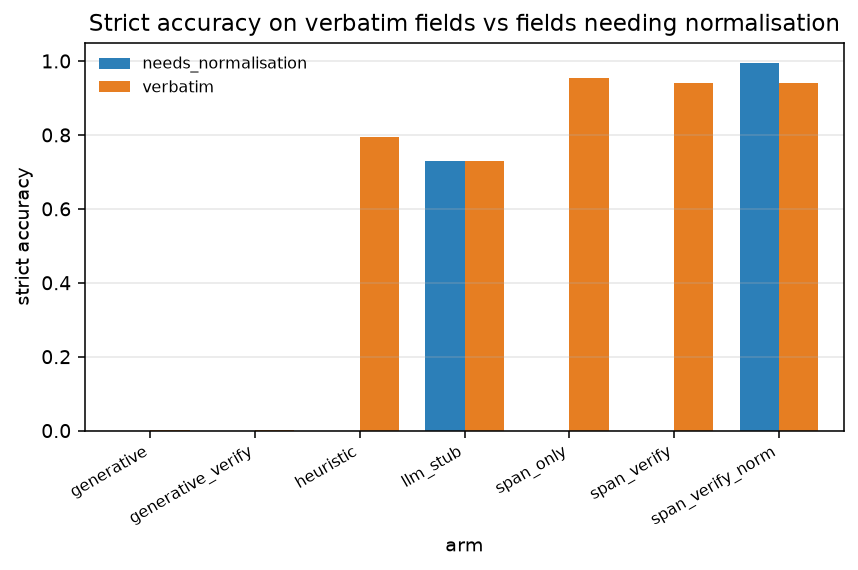

In [7]:
from IPython.display import Image
Image(filename="../results/figures/normalisation_cost.png")